# Data Collecting

dataset yang kita gunakan untuk memprediksi komoditas daging sapi di bersumber dari kaggle yang dapat diakses melalui link berikut:
[https://www.kaggle.com/datasets/ghatfanemeryrazan/trend-komoditas-dataset](https://www.kaggle.com/datasets/ghatfanemeryrazan/trend-komoditas-dataset)

In [73]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
file_path = "dataset/komoditas_daging_sapi_2022_2026.csv"
df = pd.read_csv(file_path)

# Exploratory Data Analysis


In [75]:
# Menampilkan 5 data awal untuk memastikan data terbaca
print(df.head())

  Date_Scraped  Date_Param  Commodity_ID Commodity_Name  Province_ID  \
0   2026-02-12  2022-01-01             3    Daging Sapi            1   
1   2026-02-12  2022-01-01             3    Daging Sapi            2   
2   2026-02-12  2022-01-01             3    Daging Sapi            3   
3   2026-02-12  2022-01-01             3    Daging Sapi            4   
4   2026-02-12  2022-01-01             3    Daging Sapi            5   

    Province_Name     Price  Price_Type  
0            Aceh  140400.0           1  
1  Sumatera Utara  128150.0           1  
2  Sumatera Barat  135000.0           1  
3            Riau  117900.0           1  
4  Kepulauan Riau  112450.0           1  


In [76]:
df.describe()

,Commodity_ID,Province_ID,Price,Price_Type
count,47210.0,47210.000000,47210.000000,47210.0
mean,3.0,17.500657,134883.952552,1.0
std,0.0,9.807588,12043.627989,0.0
min,3.0,1.000000,84850.000000,1.0
25%,3.0,9.000000,128250.000000,1.0
50%,3.0,17.000000,135650.000000,1.0
75%,3.0,26.000000,141650.000000,1.0
max,3.0,34.000000,218750.000000,1.0


In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47210 entries, 0 to 47209
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date_Scraped    47210 non-null  str    
 1   Date_Param      47210 non-null  str    
 2   Commodity_ID    47210 non-null  int64  
 3   Commodity_Name  47210 non-null  str    
 4   Province_ID     47210 non-null  int64  
 5   Province_Name   47210 non-null  str    
 6   Price           47210 non-null  float64
 7   Price_Type      47210 non-null  int64  
dtypes: float64(1), int64(3), str(4)
memory usage: 2.9 MB


In [78]:
df.shape

(47210, 8)

In [79]:
df.isnull().sum()

Date_Scraped      0
Date_Param        0
Commodity_ID      0
Commodity_Name    0
Province_ID       0
Province_Name     0
Price             0
Price_Type        0
dtype: int64

In [80]:
df.duplicated().sum()

np.int64(0)


==== Deteksi Outlier dengan IQR pada kolom Price ====
Batas Bawah : 108150.0
Batas Atas  : 161750.0
Jumlah Price Outlier : 2064 baris dari total 47210 baris data


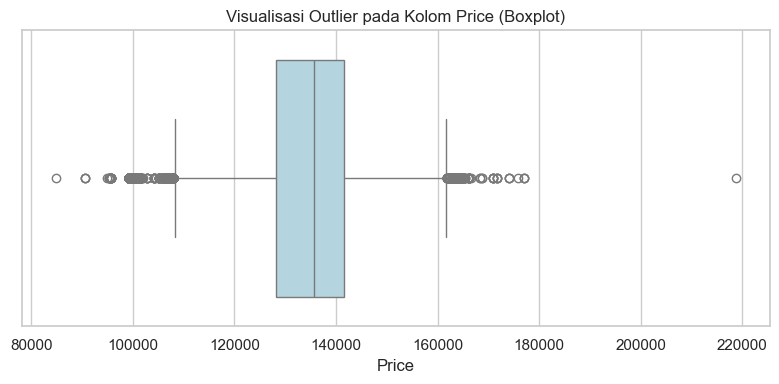

In [81]:
# DETEKSI DAN VISUALISASI OUTLIER (PENCILAN)

kolom_target = 'Price' 

print(f"\n==== Deteksi Outlier dengan IQR pada kolom {kolom_target} ====")

Q1 = df[kolom_target].quantile(0.25)
Q3 = df[kolom_target].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mencari data yang berada di luar batas (outlier)
outliers = df[(df[kolom_target] < lower_bound) | (df[kolom_target] > upper_bound)]
print(f"Batas Bawah : {lower_bound}")
print(f"Batas Atas  : {upper_bound}")
print(f"Jumlah {kolom_target} Outlier : {len(outliers)} baris dari total {len(df)} baris data")

# Visualisasi Outlier dengan Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df[kolom_target], color='lightblue')
plt.title(f'Visualisasi Outlier pada Kolom {kolom_target} (Boxplot)')
plt.xlabel(kolom_target)
plt.tight_layout()
plt.show()


# Data Preprocessing

In [82]:
print(f"Jumlah data sebelum dihapus: {len(df)}")

# Menghapus baris yang nilai harganya di bawah batas bawah atau di atas batas atas
df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

print(f"Jumlah data setelah dihapus: {len(df)}")

Jumlah data sebelum dihapus: 47210
Jumlah data setelah dihapus: 45146


In [83]:
# Memilih kolom yang penting untuk analisis
# Kita gunakan:
# - Date_Param sebagai tanggal
# - Province_Name sebagai provinsi
# - Price sebagai target harga
df = df[["Date_Param", "Province_Name", "Price"]]

# Mengubah kolom tanggal ke format datetime
df["Date_Param"] = pd.to_datetime(df["Date_Param"])

# Membuat fitur dari tanggal
# Fitur ini digunakan agar model dapat membaca pola waktu
df["Tahun"] = df["Date_Param"].dt.year
df["Bulan"] = df["Date_Param"].dt.month
df["Hari"] = df["Date_Param"].dt.day
df["Hari_dalam_Minggu"] = df["Date_Param"].dt.dayofweek

# Mengubah nama provinsi menjadi angka
# Model machine learning hanya bisa membaca data numerik
df["Kode_Provinsi"] = df["Province_Name"].astype("category").cat.codes

In [84]:
# Menampilkan informasi dataset
print(df.info())

<class 'pandas.DataFrame'>
Index: 45146 entries, 0 to 47209
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date_Param         45146 non-null  datetime64[us]
 1   Province_Name      45146 non-null  str           
 2   Price              45146 non-null  float64       
 3   Tahun              45146 non-null  int32         
 4   Bulan              45146 non-null  int32         
 5   Hari               45146 non-null  int32         
 6   Hari_dalam_Minggu  45146 non-null  int32         
 7   Kode_Provinsi      45146 non-null  int8          
dtypes: datetime64[us](1), float64(1), int32(4), int8(1), str(1)
memory usage: 2.1 MB
None


In [85]:
# Menentukan fitur (X) dan target (y)
# X = data input
# y = harga yang akan diprediksi
X = df[["Kode_Provinsi", "Tahun", "Bulan", "Hari", "Hari_dalam_Minggu"]]
y = df["Price"]

# Membagi data menjadi data latih dan data uji
# 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Training

In [86]:
# Membuat model Random Forest Regressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Melatih model menggunakan data latih
model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
y_pred = model.predict(X_test)

## Visualisasi

C:\Users\Acer\AppData\Local\Temp\ipykernel_18948\3489032048.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, color='red')


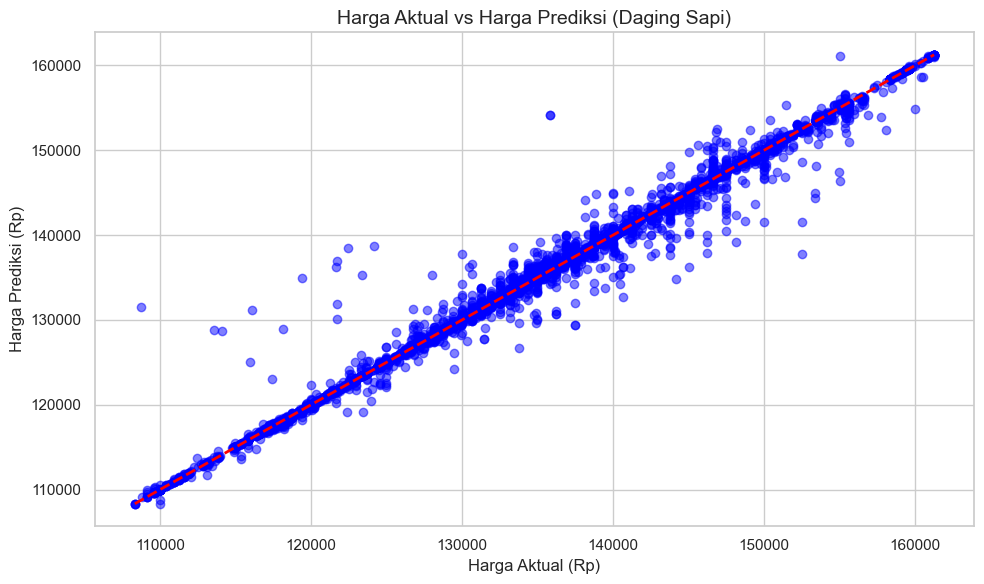

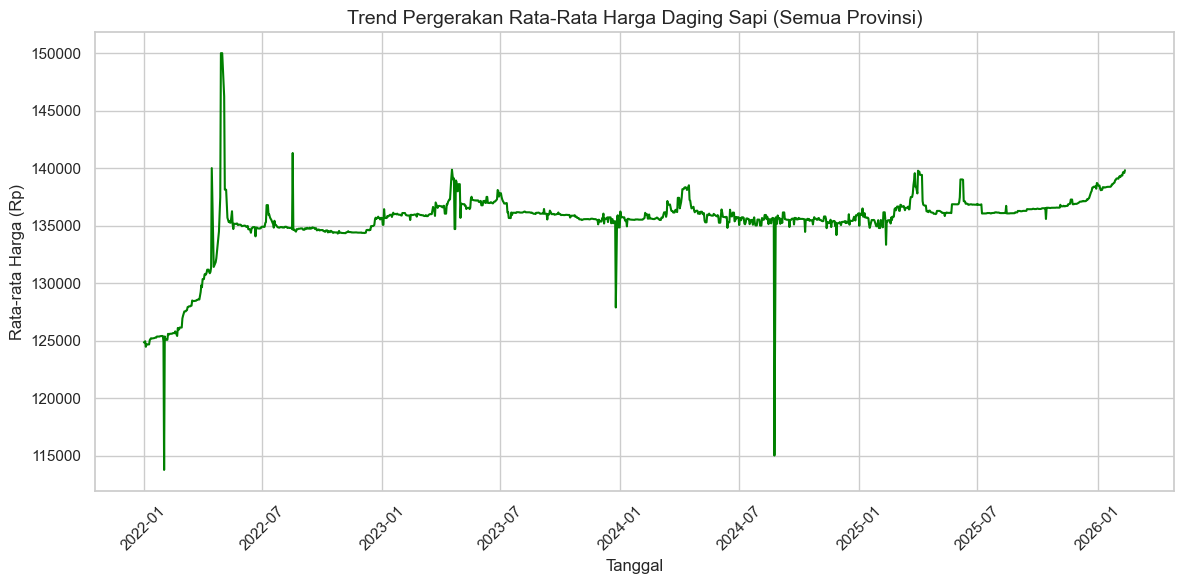

In [87]:
# Mengatur gaya plot
sns.set_theme(style="whitegrid")

# VISUALISASI 1: Harga Aktual vs Harga Prediksi (Scatter Plot)
# Untuk melihat seberapa akurat prediksi model terhadap data asli.
# Semakin titik-titik mendekati garis putus-putus hitam, semakin baik modelnya.
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')

# Membuat garis referensi diagonal (jika tebakan 100% akurat)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, color='red')

plt.title('Harga Aktual vs Harga Prediksi (Daging Sapi)', fontsize=14)
plt.xlabel('Harga Aktual (Rp)', fontsize=12)
plt.ylabel('Harga Prediksi (Rp)', fontsize=12)
plt.tight_layout()
plt.show()

# VISUALISASI 2: Trend Pergerakan Harga Aktual Seiring Waktu
# Melihat rata-rata harga daging sapi dari tahun 2022 hingga 2026
plt.figure(figsize=(12, 6))

# Menghitung rata-rata harga per tanggal di seluruh provinsi
trend_data = df.groupby('Date_Param')['Price'].mean().reset_index()

plt.plot(trend_data['Date_Param'], trend_data['Price'], color='green', linewidth=1.5)
plt.title('Trend Pergerakan Rata-Rata Harga Daging Sapi (Semua Provinsi)', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Rata-rata Harga (Rp)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Evaluasi Model

| Metrik | Digunakan ketika                                          |
| ------ | --------------------------------------------------------- |
| MAE    | Jika Ingin mengetahui rata-rata kesalahan secara langsung |
| MSE    | Jika Error besar harus dihukum lebih berat                |
| RMSE   | Jika Ingin ukuran error yang mudah diinterpretasikan      |
| R²     | Jika Ingin melihat seberapa baik model menjelaskan data   |


In [88]:
# Menghitung evaluasi model
# MAE  = Mean Absolute Error
# RMSE = Root Mean Squared Error

r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== EVALUASI MODEL ===")
print("r2  :", round(r2, 2))
print("MSE  :", round(mse, 2))
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))

# Menampilkan contoh hasil prediksi
hasil_uji = pd.DataFrame({
    "Harga Asli": y_test.values[:10],
    "Harga Prediksi": y_pred[:10]
})

print("\n=== CONTOH HASIL PREDIKSI ===")
print(hasil_uji)


=== EVALUASI MODEL ===
r2  : 0.99
MSE  : 978514.79
MAE  : 262.11
RMSE : 989.2

=== CONTOH HASIL PREDIKSI ===
   Harga Asli  Harga Prediksi
0    117000.0        117010.0
1    128350.0        128350.0
2    128750.0        128750.0
3    147500.0        147500.0
4    154100.0        154100.0
5    138750.0        138750.0
6    149600.0        149608.0
7    136250.0        136250.0
8    130000.0        130099.0
9    141250.0        141206.5


# Deployment

In [89]:
# # Membuat mapping kode provinsi
# # Agar user tahu angka mana untuk provinsi tertentu
# mapping_provinsi = dict(enumerate(df["Province_Name"].astype("category").cat.categories))

# print("\n=== DAFTAR KODE PROVINSI ===")
# for kode, prov in mapping_provinsi.items():
#     print(f"{kode} : {prov}")# Membuat mapping kode provinsi

# # Input data baru dari pengguna
# # User memilih provinsi dan tanggal
# print("\n=== PREDIKSI HARGA BARU ===")
# kode_provinsi = int(input("Masukkan kode provinsi: "))
# tahun = int(input("Masukkan tahun: "))
# bulan = int(input("Masukkan bulan: "))
# hari = int(input("Masukkan hari: "))

# # Menghitung hari dalam minggu dari tanggal input
# tanggal_baru = pd.Timestamp(year=tahun, month=bulan, day=hari)
# hari_dalam_minggu = tanggal_baru.dayofweek

# # Menyiapkan data baru ke dalam DataFrame
# data_baru = pd.DataFrame([{
#     "Kode_Provinsi": kode_provinsi,
#     "Tahun": tahun,
#     "Bulan": bulan,
#     "Hari": hari,
#     "Hari_dalam_Minggu": hari_dalam_minggu
# }])

# # Melakukan prediksi harga untuk data baru
# prediksi_baru = model.predict(data_baru)[0]

# # Menampilkan hasil prediksi akhir
# print("\n=== HASIL PREDIKSI BARU ===")
# print("Provinsi        :", mapping_provinsi.get(kode_provinsi, "Tidak diketahui"))
# print("Tanggal         :", tanggal_baru.date())
# print("Prediksi Harga  :", round(prediksi_baru, 2))
# print("Komoditas       : Daging Sapi")